In [1]:
library(Seurat)
library(escape)
library(dplyr)
library(ggplot2)
library(ggnewscale)
library(scRepertoire)
library(immunarch)
library(tidyr)
library(ggrepel)


Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Loading required package: dtplyr

Loading required package: data.table

Warning message:
“package ‘data.table’ was built under R version 4.4.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dp

# Load Data

In [2]:
t_cells <- readRDS('seurat_objects/t_cells_so.rds')

In [3]:
vdjdb = dbLoad("/home/workspace/manuscript/database/vdjdb.txt", "vdjdb", .species = "HomoSapiens")

In [4]:
sort(colnames(vdjdb))

[1] "Chain"            "Pathology"        "Species"          "antigen.epitope" 
 [5] "antigen.gene"     "antigen.species"  "cdr3"             "cdr3fix"         
 [9] "complex.id"       "gene"             "j.segm"           "meta"            
[13] "method"           "mhc.a"            "mhc.b"            "mhc.class"       
[17] "reference.id"     "species"          "v.segm"           "vdjdb.pgen.score"
[21] "vdjdb.score"      "web.cdr3fix.nc"   "web.cdr3fix.unmp" "web.method"      
[25] "web.method.seq"

In [5]:
vdjdb_filtered <- vdjdb %>%
    filter(mhc.a %in% c('HLA-A*02','HLA-A*02:01'))

# Build CDR3 Lookup table

In [6]:
vdj_lookup <- vdjdb_filtered %>%
    select(cdr3, Pathology, vdjdb.score) %>%
    distinct() %>%
    group_by(cdr3) %>%
    slice_max(order_by = vdjdb.score, n = 1, with_ties = TRUE) %>%
    summarise(
        Path_List = paste(sort(unique(Pathology)), collapse = "; "), 
        Max_Score = max(vdjdb.score),
        .groups = "drop"
    )
head(vdj_lookup)

cdr3,Path_List,Max_Score
<chr>,<chr>,<dbl>
AQGLLTGGGNKLTF,HCV,0
ASMFSGGGNEKFTF,HCV,0
ASMYKGGGNEKFTF,HCV,0
CAAAAGNMLTF,EBV,0
CAAAAGRRALTF,CMV,0
CAAAATPGNTGKLIF,InfluenzaA,0


In [7]:
metadata <- t_cells@meta.data %>%
    left_join(vdj_lookup, by = c("CDR3a" = "cdr3")) %>%
    rename(Path_Alpha = Path_List) %>%
    left_join(vdj_lookup, by = c("CDR3b" = "cdr3")) %>%
    rename(Path_Beta = Path_List)

In [8]:
metadata <- metadata %>%
    unite("Pathology", Path_Alpha, Path_Beta, sep = "; ", na.rm = TRUE) %>%
    mutate(Pathology = ifelse(Pathology == "", "No Match", Pathology)) %>%
    mutate(Pathology = sapply(strsplit(Pathology, "; "), function(x) paste(unique(trimws(x)), collapse = "; ")))

In [9]:
table(metadata$barcodes == colnames(t_cells[['RNA']]))


  TRUE 
105457 

In [10]:
t_cells$Pathology <- metadata$Pathology

# Calculate increase over Null Peptide

In [11]:
## Establish clone leaderboard
leaderboard_df <- t_cells@meta.data %>%
    # filter(Day == "Day_10") %>%
    filter(!is.na(CTaa)) %>%
    group_by(Donor, Day, Peptide, CTaa, Pathology, CDR3a) %>%
    summarise(count = n(), .groups = "drop") %>%
    group_by(Donor, Day, Peptide,) %>%
    mutate(prop = count / sum(count)) %>%
    ungroup()

In [12]:
## Establish baseline dataframe from Null peptide condition
baseline <- leaderboard_df %>%
    filter(Peptide == "Null" & Day == 'Day_0') %>%
    select(Donor, CTaa, null_prop = prop)

In [13]:
## Establish peptide stim dataframe and filter to top 5 per pathogen
enrichment_base <- leaderboard_df %>%
    filter(Peptide != "Null" & Day == 'Day_10') %>%
    left_join(baseline, by = c("Donor", "CTaa")) %>%
    mutate(
        null_prop = replace_na(null_prop, 0),
        prop = replace_na(prop, 0),
        delta = prop - null_prop,
        Pathology = replace_na(Pathology, "No Match")
    )

top_5_clones_cefsx <- enrichment_base %>%
    filter(Peptide == 'CEFSX') %>%
    filter(!is.na(CTaa)) %>%
    filter(!grepl("NA", CTaa)) %>%
    filter(!grepl("[*_]", CDR3a)) %>%
    group_by(Donor, Pathology) %>%
    slice_max(order_by = delta, n = 5, with_ties = FALSE) %>%
    ungroup() %>%    
    filter(Pathology %in% c("EBV", "CMV", "InfluenzaA", "SARS-CoV-2", "No Match")) %>%
    select(CTaa)

In [14]:
top_5_ebv_clones <- enrichment_base %>%
    filter(Peptide == 'EBV') %>%
    filter(!is.na(CTaa)) %>%
    filter(!grepl("NA", CTaa)) %>%
    filter(!grepl("[*_]", CDR3a)) %>%
    group_by(Donor, Pathology) %>%
    slice_max(order_by = delta, n = 5, with_ties = FALSE) %>%
    ungroup() %>%    
    filter(Pathology == "EBV") %>%
    select(CTaa)

In [15]:
enrichment_filtered <- enrichment_base %>% 
    filter(CTaa %in% c(top_5_clones_cefsx$CTaa,top_5_ebv_clones$CTaa))
head(enrichment_filtered)

Donor,Day,Peptide,CTaa,Pathology,CDR3a,count,prop,null_prop,delta
<fct>,<fct>,<fct>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
2164,Day_10,CEFSX,CAATISIYNQGGKLIF_CASMPLAGGSGYTF,No Match,CAATISIYNQGGKLIF,36,0.0035218157,0.0001502855,0.0033715301
2164,Day_10,CEFSX,CAEFRAGGGADGLTF_CASSQSPGGTQYF,EBV,CAEFRAGGGADGLTF,16,0.0015652514,0.0000000000,0.0015652514
2164,Day_10,CEFSX,CAFMKDAGGTSYGKLTF_CASSIGVYGYTF,InfluenzaA,CAFMKDAGGTSYGKLTF,9,0.0008804539,0.0000000000,0.0008804539
2164,Day_10,CEFSX,CAGGGSGNTGKLIF_CASSIRSSYEQYF,InfluenzaA,CAGGGSGNTGKLIF,7,0.0006847975,0.0000000000,0.0006847975
2164,Day_10,CEFSX,CAGGYQKVTF_CATSTQDGLWGEQFF,CMV,CAGGYQKVTF,27,0.0026413618,0.0001502855,0.0024910762
2164,Day_10,CEFSX,CAMKAAGNKLTF_CASLGGVYTF,CMV,CAMKAAGNKLTF,15,0.0014674232,0.0000000000,0.0014674232


In [19]:
enrichment_filtered %>% 
    slice_max(order_by = delta, n=10)

Donor,Day,Peptide,CTaa,Pathology,CDR3a,count,prop,null_prop,delta
<fct>,<fct>,<fct>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
3446,Day_10,CEFSX,CAGKTSYDKVIF_CASSPGDEQFF,CMV,CAGKTSYDKVIF,572,0.051480515,0.0015598752,0.049920640
2164,Day_10,CEFSX,CAVKAAGNKLTF_CASMGDTIYF,SARS-CoV-2,CAVKAAGNKLTF,364,0.035609470,0.0003005711,0.035308899
3446,Day_10,CEFSX,CADETGGGNKLTF_CSARDVVQGDFRIGYTF,No Match,CADETGGGNKLTF,357,0.032130321,0.0015598752,0.030570446
3446,Day_10,CEFSX,CALYQAGTALIF_CASSLARGANYEQYF,No Match,CALYQAGTALIF,185,0.016650167,0.0008399328,0.015810234
2164,Day_10,CEFSX,CAVRAAGNKLTF_CASMGDTQYF,CMV,CAVRAAGNKLTF,163,0.015945999,0.0001502855,0.015795713
2164,Day_10,CEFSX,CAMWTGFQKLVF_CASSMGTGGEAFF,No Match,CAMWTGFQKLVF,120,0.011739386,0.0001502855,0.011589100
3446,Day_10,EBV,CAESTSGGKLIF_CSVGTGGTNEKLFF,EBV,CAESTSGGKLIF,90,0.008209432,0.0008399328,0.007369499
2164,Day_10,CEFSX,CAMREGSRGNNRLAF_CASFDSSYEQYF,No Match,CAMREGSRGNNRLAF,75,0.007337116,0.0000000000,0.007337116
2164,Day_10,CEFSX,CAVKAAGNKLTF_CASMGDSQYF,SARS-CoV-2,CAVKAAGNKLTF,67,0.006554490,0.0001502855,0.006404205


In [26]:
min((enrichment_filtered %>% 
    filter(null_prop != 0))$null_prop)

[1] 0.0001199904

# Plot

Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


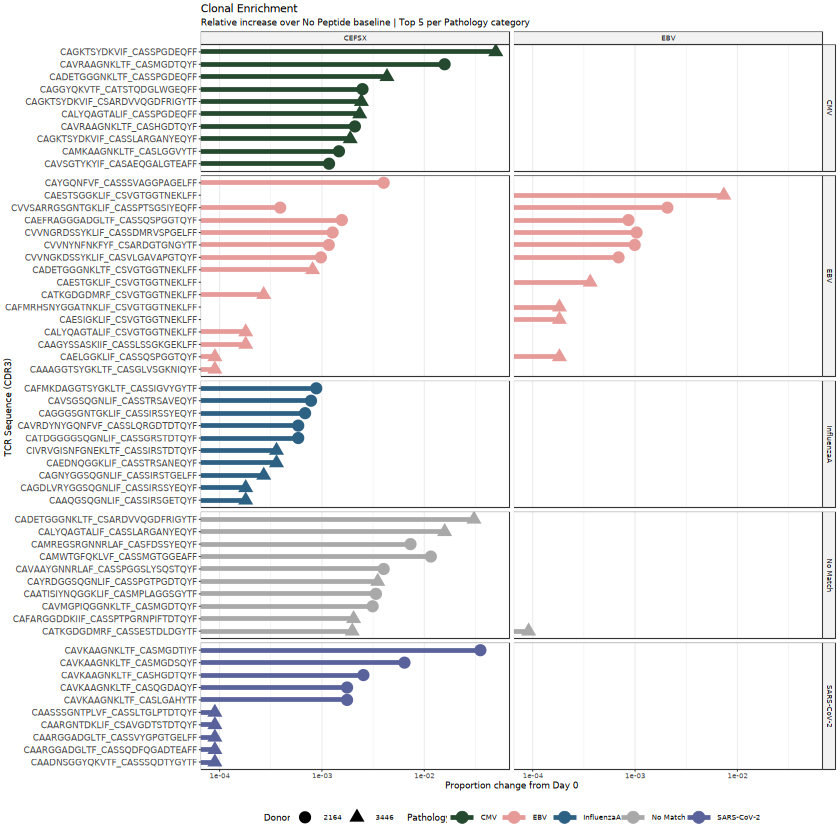

In [43]:
options(repr.plot.width = 7, repr.plot.height = 7)
ggplot(enrichment_filtered, aes(x = reorder(CTaa, delta), y = delta, color = Pathology)) +
    geom_segment(aes(xend = reorder(CTaa, delta), yend = 0), linewidth = 1) +
    geom_point(aes(shape = Donor), size = 3) +
    scale_y_log10() +
    coord_flip() +
    facet_grid(Pathology ~ Peptide, scales = "free_y", space = "free_y") + 
    theme_bw(base_size = 5) +
    theme(
        axis.text.y = element_text( size = 5),
        panel.grid.major.y = element_blank(),
        legend.position = "bottom",
        strip.background = element_rect(fill = "grey95")
    ) +
    scale_color_manual(values = c(
        "EBV" = "#e69b99", 
        "CMV" = "#24492e", 
        "InfluenzaA" = "#2c6184", 
        "SARS-CoV-2" = "#59629b",
        "No Match" = 'darkgrey'
    )) +
    labs(
        title = "Clonal Enrichment",
        subtitle = "Relative increase over No Peptide baseline | Top 5 per Pathology category",
        x = "TCR Sequence (CDR3)",
        y = "Proportion change from Day 0"
        # color = "Matched Pathology"
    )

In [44]:
# Open the PDF graphics device
pdf("plots/Supp_General_Peptide_Expansion_lollipop.pdf", width = 7, height = 7) # You can specify width and height in inches

# Create your plot
ggplot(enrichment_filtered, aes(x = reorder(CTaa, delta), y = delta, color = Pathology)) +
    geom_segment(aes(xend = reorder(CTaa, delta), yend = 0), linewidth = 1) +
    geom_point(aes(shape = Donor), size = 3) +
    scale_y_log10() +
    coord_flip() +
    facet_grid(Pathology ~ Peptide, scales = "free_y", space = "free_y") + 
    theme_bw(base_size = 5) +
    theme(
        axis.text.y = element_text(size = 5),
        panel.grid.major.y = element_blank(),
        legend.position = "bottom",
        strip.background = element_rect(fill = "grey95")
    ) +
    scale_color_manual(values = c(
        "EBV" = "#e69b99", 
        "CMV" = "#24492e", 
        "InfluenzaA" = "#2c6184", 
        "SARS-CoV-2" = "#59629b",
        "No Match" = 'darkgrey'
    )) +
    labs(
        title = "Clonal Enrichment",
        subtitle = "Relative increase over No Peptide baseline | Top 5 per Pathology category",
        x = "TCR Sequence (CDR3)",
        y = "Proportion change from Day 0"
    )
# Close the graphics device to save the plot
dev.off()

Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


pdf 
  2